# Knee Injuries Classification Project
## MRNet Classifier Notebook 

### Data source: 
#### Stanford AIMI. (2026). MRNet: Knee MRI's (Version 1.0) [Dataset]. Redivis. https://stanford.redivis.com/datasets/4a2c-4cpkzrn2c?v=1.0


In [ ]:
# MRNet Environment Setup (Run this cell first)
from google.colab import drive
import os


### Only use the following code when you want to add the zipped folder to your drive.
This might take up to 40 minutes to run but it is a one time thing. If you can somehow create the .zip folder in your drive than you do not need to run this code. 

In [ ]:
drive.mount('/content/drive')
# 1. Define paths
# SOURCE: Your mounted Google Drive folder
# since you might have the files in a subfolder, make sure to create a folder shortcut in your Drive for easier access
shared_folder_path = '/content/drive/MyDrive/mrnet_images' 

# DESTINATION: The local, ultra-fast Colab cloud SSD storage
local_zip_path = '/content/mrnet_images.zip'

print("Starting optimized compression onto local cloud SSD...")

# 2. Zip from Drive directly to the local cloud SSD
!zip -rq "{local_zip_path}" "{shared_folder_path}"

print("Compression to local SSD complete! Now uploading the single file back to your Drive...")

# 3. Copy the single large zip back to Google Drive in one efficient burst
!cp "{local_zip_path}" "/content/drive/MyDrive/"

print("All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.")

### Loading data into Colab SSD 
When you already have your zip folder in you "MyDrive", we can start from here to git the data unziped inside the colab SSD. 

In [23]:
# 1. Mount persistent storage
drive.mount('/content/drive')

# 2. Extract dataset to local VM SSD
if not os.path.exists('/content/mrnet_images'):
    print("Transferring optimized archive to local cloud SSD...")
    !cp /content/drive/MyDrive/mrnet_images.zip /content/
    
    print("Unpacking MRI volumes locally...")
    !unzip -q /content/mrnet_images.zip -d /content/
    
    # Clean up the zip file from local memory to save space
    !rm /content/mrnet_images.zip
    print("Environment Ready!")
else:
    print("Data already unpacked and ready on local SSD.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Transferring optimized archive to local cloud SSD...
Unpacking MRI volumes locally...
Environment Ready!


In [24]:
# Move the folder to the standard /content/mrnet_images location
!mv /content/content/drive/MyDrive/mrnet_images /content/mrnet_images

# Clean up the accidental empty duplicate directories
!rm -rf /content/content

print("Folder successfully moved! Verified content:")
import os
print(os.listdir('/content/mrnet_images'))

Folder successfully moved! Verified content:
['.DS_Store', 'axial', 'valid_files', 'sagittal', 'labels', 'coronal']


In [25]:
import numpy as np

# Load a single case (using 0212.npy which we saw in your earlier screenshot logs)
sample_volume = np.load('/content/mrnet_images/axial/0212.npy')

print("Data Type:", type(sample_volume))
print("Volume Shape:", sample_volume.shape)

Data Type: <class 'numpy.ndarray'>
Volume Shape: (46, 256, 256)


Array Shape: (26, 256, 256)


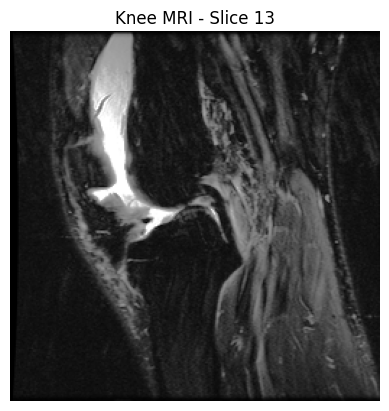

In [26]:
import matplotlib.pyplot as plt

# 1. Load one of your downloaded files (replace with your actual file path)
# Let's grab a random one from your sagittal or axial folder
mri_volume = np.load('/content/mrnet_images/sagittal/0001.npy')

# 2. Check its dimensions
print("Array Shape:", mri_volume.shape)

# 3. Visualize a slice from the middle of the stack
middle_slice_idx = mri_volume.shape[0] // 2

plt.imshow(mri_volume[middle_slice_idx], cmap="gray")
plt.axis("off")
plt.title(f"Knee MRI - Slice {middle_slice_idx}")
plt.show()

In [27]:
import pandas as pd
label_data = pd.read_csv("/content/mrnet_images/labels/Redivis-files-2026-05-18.csv")
print(label_data.head())
print(label_data.columns)
print(label_data["Folder"].value_counts())
print(label_data.describe())


             Name Folder
0  axial/0000.npy  train
1  axial/0001.npy  train
2  axial/0002.npy  train
3  axial/0003.npy  train
4  axial/0004.npy  train
Index(['Name', 'Folder'], dtype='object')
Folder
train    3390
valid     360
Name: count, dtype: int64
                     Name Folder
count                3750   3750
unique               3750      2
top     sagittal/1249.npy  train
freq                    1   3390


Array Shape: (27, 256, 256)


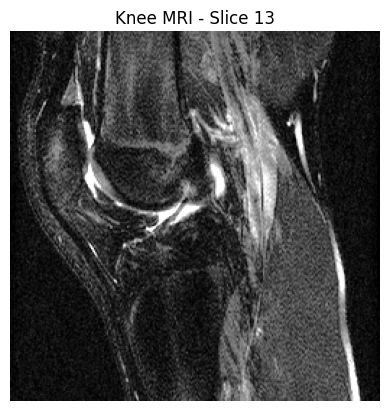

In [28]:
# 1. Load one of your downloaded files (replace with your actual file path)
# Let's grab a random one from your sagittal or axial folder
mri_volume = np.load("mrnet_images/valid_files/sagittal/1130.npy")

# 2. Check its dimensions
print("Array Shape:", mri_volume.shape)

# 3. Visualize a slice from the middle of the stack
middle_slice_idx = mri_volume.shape[0] // 2

plt.imshow(mri_volume[middle_slice_idx], cmap="gray")
plt.axis("off")
plt.title(f"Knee MRI - Slice {middle_slice_idx}")
plt.show()